<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Amazon-Reviews-Sentiment-Analysis-Using-NLP/blob/main/Amazon-Reviews-Sentiment-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

Introduction

The objective of this project is to classify Amazon customer reviews
as positive or negative using Natural Language Processing (NLP)
and machine learning techniques.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/amazonreviews.tsv", sep="\t")

In [ ]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


The dataset is provided in TSV format and contains two columns:
`label` and `review`.

In [ ]:
df.shape

(10000, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


The dataset contain 1000 rows and 2 columns of datatype object.

# Data Cleaning

In [ ]:
df.isnull().sum()

,0
label,0
review,0


There is no null values.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


There are no duplicates in the dataset.

In [ ]:
print(df["label"].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


The dataset contains 5097 negative reviews and 4903 positive reviews.

In [ ]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
#For sentiment analysis, blindly removing every stopword isn't always ideal.
negation_words = {"not", "no", "never"}
stop_words = stop_words - negation_words

In [ ]:
def clean_text(text):
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Join words back together
    return " ".join(words)

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

In [ ]:
print(df[["review", "clean_review"]].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hands i...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


# Exploratory Analysis

Visualize the sentiment distribution

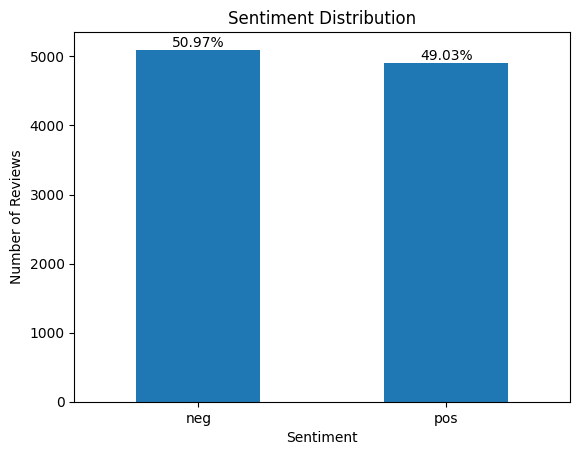

In [ ]:
import matplotlib.pyplot as plt
counts = df["label"].value_counts()
percentages = df["label"].value_counts(normalize=True) * 100
ax = counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
# Add percentage labels
for i, percentage in enumerate(percentages):
    ax.text(i, counts.iloc[i], f"{percentage:.2f}%",
            ha="center", va="bottom")
plt.show()

Word Cloud Analysis

In [ ]:
pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Positive WordCloud

In [ ]:
#Combine positive reviews
positive_text = " ".join(
    df[df["label"] == "pos"]["clean_review"]
)

In [ ]:
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

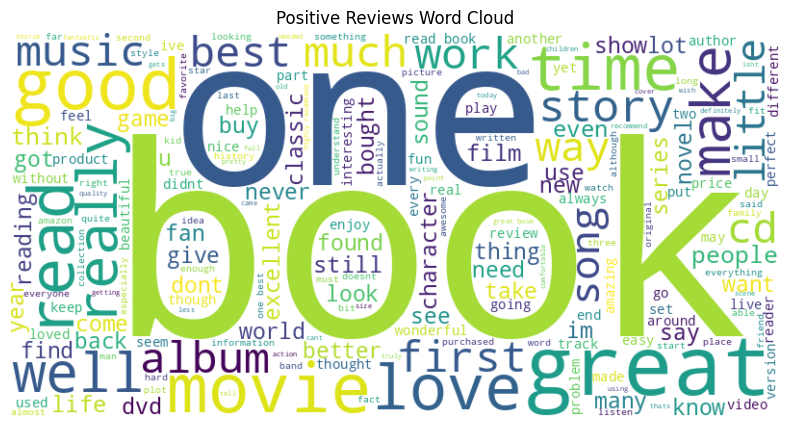

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

Negative WordCloud

In [ ]:
#Combine negative reviews
negative_text = " ".join(
    df[df["label"] == "neg"]["clean_review"]
)

In [ ]:
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

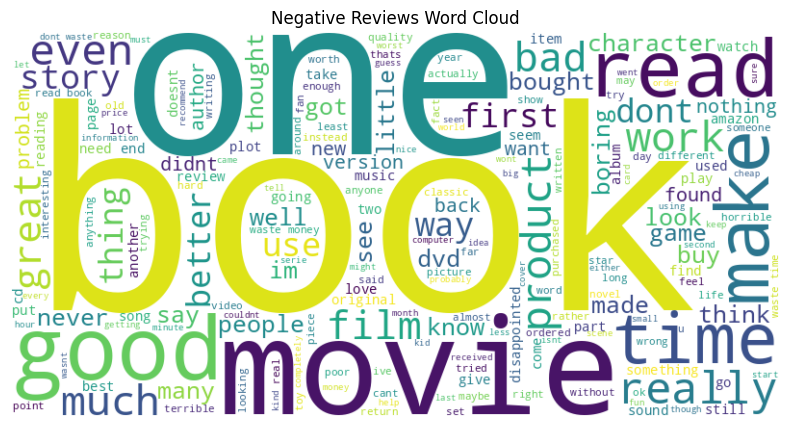

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

Count common words in positive reviews

In [ ]:
from collections import Counter
positive_words = " ".join(
    df[df["label"] == "pos"]["clean_review"]
).split()
positive_word_counts = Counter(positive_words)
print(positive_word_counts.most_common(10))

[('book', 3313), ('great', 2087), ('not', 1932), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902)]


Count common words in negative reviews

In [ ]:
negative_words = " ".join(
    df[df["label"] == "neg"]["clean_review"]
).split()
negative_word_counts = Counter(negative_words)
print(negative_word_counts.most_common(10))

[('not', 4399), ('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('no', 1220), ('read', 1187), ('get', 1139)]


Visualize positive words

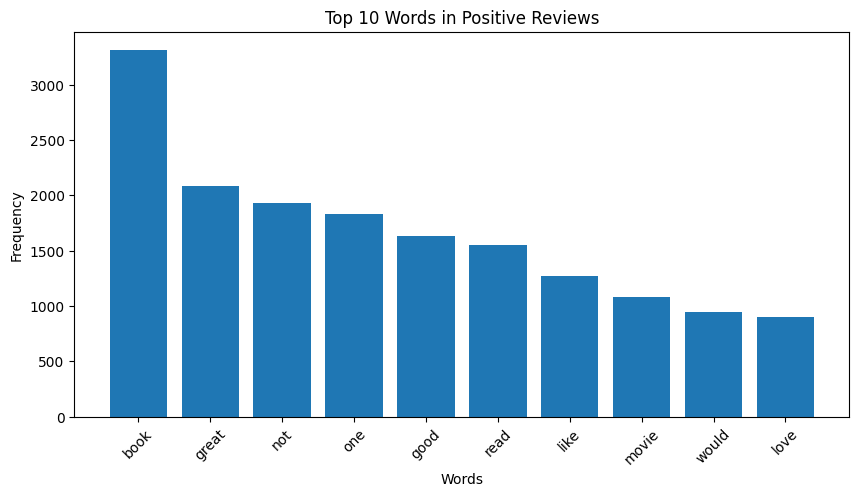

In [ ]:
positive_top10 = positive_word_counts.most_common(10)
words = [word for word, count in positive_top10]
counts = [count for word, count in positive_top10]
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

Visualize negative words

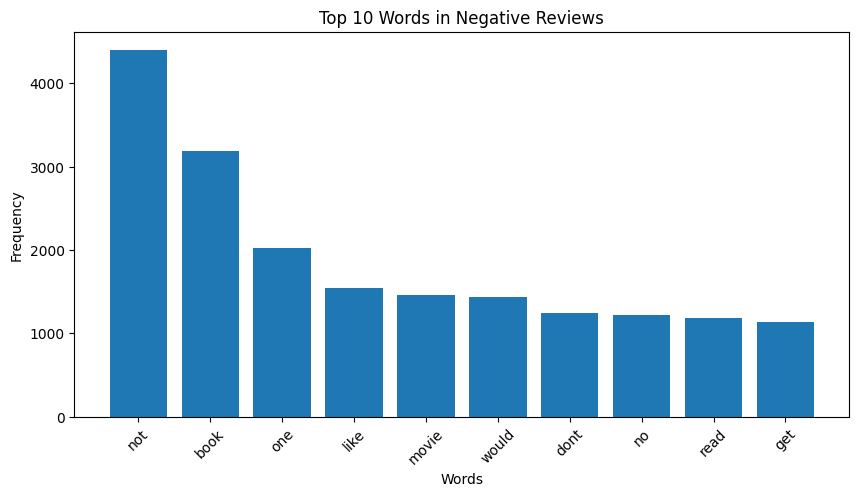

In [ ]:
negative_top10 = negative_word_counts.most_common(10)
words = [word for word, count in negative_top10]
counts = [count for word, count in negative_top10]
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Model Development

In [ ]:
#Seperate features and target
X = df["clean_review"]
y = df["label"]

In [ ]:
#Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

We should not fit TF-IDF on the entire dataset before splitting because that allows information from the test set to influence the feature extraction process.

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


TF-IDF Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Create the vectorizer
tfidf = TfidfVectorizer(
    max_features=5000
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (8000, 5000)
Testing shape: (2000, 5000)


Build the Logistic Regression model

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000) #max_iter=1000 gives the model enough iterations to converge when working with a large TF-IDF feature matrix.
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

In [ ]:
#Evaluating the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="pos")
recall = recall_score(y_test, y_pred, pos_label="pos")
f1 = f1_score(y_test, y_pred, pos_label="pos")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.862
Precision: 0.8578680203045685
Recall   : 0.8613659531090724
F1 Score : 0.8596134282807731


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[879 140]
 [136 845]]


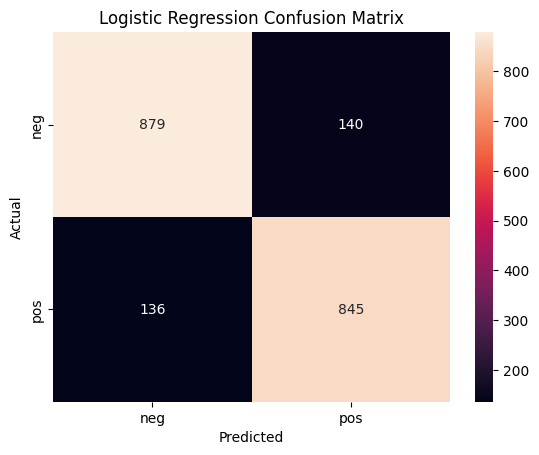

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["neg", "pos"],
    yticklabels=["neg", "pos"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Cross-validation for Logistic Regression

In [ ]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score
f1_scorer = make_scorer(
    f1_score,
    pos_label="pos"
)
cv_scores = cross_val_score(
    lr,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring=f1_scorer
)
print("CV F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

CV F1 Scores: [0.86445013 0.85477707 0.87484036 0.85916399 0.8510101 ]
Mean CV F1 Score: 0.860848328737655


Five-fold cross-validation was performed to assess the stability and generalization of the Logistic Regression model. The F1-scores across the five folds ranged from 85.10% to 87.48%, with a mean F1-score of 86.08%. The relatively small variation between the folds indicates that the model provides consistent performance across different subsets of the training data.